# **Deepfake Project**

In [1]:
!pip install -r requirements.txt


[notice] A new release of pip is available: 23.2.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
# import kagglehub
# 
# # kaggle_api = KGAT_8eb0727ee6d566add6db98054cc75b1f
# kagglehub.login()

In [3]:
# kagglehub.competition_download(
#     "ml-intensive-yandex-academy-spring-2026",
#     output_dir="./data"
# )

# **IMPORTS MODULE**

In [4]:
import os
import numpy as np
import pandas as pd
from PIL import Image
import torch
from torch import nn
import torch.optim as optim
from torchsummary import summary
from torch.utils.data import Dataset, DataLoader, random_split, Subset
from torchvision.transforms import transforms 
from torchmetrics import F1Score
import matplotlib.pyplot as plt
from IPython.display import clear_output
from sklearn.model_selection import train_test_split

# **DATASET MODULE**

In [5]:
def dir_length(
        path: str
) -> int:
    abs_path = os.path.abspath(path)
    return len(os.listdir(abs_path))


class CustomDataset(Dataset):
    def __init__(
            self,
            data: list[tuple[str, int]],
            _transform = None
    ):
        self.data = data
        self._transform = _transform
    
    def __len__(self):
        return len(self.data)
    
    def __getitem__(
            self,
            index: int
    ):
        image = Image.open(
            self.data[index][0]
        ).convert("RGB")   
        label = self.data[index][1]
        
        if self._transform:
            image = self._transform(image)
        
        return image, label
    

def load_all_data(
        root_dir: str,
        csv_path: str = None
):
    _data = []
    solutions_data = pd.read_csv(
        csv_path, names=["id", "label"]
    ) if csv_path else None
    length = dir_length(root_dir)
    for ind in range(length):
        _data.append(
            (
                os.path.join(root_dir, f"{ind}.jpg"),
                solutions_data.iloc[ind]["label"] if csv_path else ind
            )
        )
    
    return _data

# **PARAMS MODULE**

In [6]:
IMAGE_SIZE = (256, 256)

BATCH_SIZE = 128

LEARNING_RATE = 0.01

criterion = nn.BCEWithLogitsLoss()

DEVICE = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

SOLUTION_FILE_PATH = "./data/dataset/train_solution.csv"
TRAIN_IMAGES_DIR = "./data/dataset/train_images"
MODEL_WEIGHTS_PATH = "./weights/model_weights.pth"
TEST_IMAGES_DIR = "./data/dataset/test_images"

# **DATALOAD MODULE**

In [7]:
train_transform = transforms.Compose([
    transforms.RandomResizedCrop(
        size=IMAGE_SIZE,
        scale=(0.7, 1.0),
        ratio=(0.9, 1.1)
    ),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=15),
    transforms.ColorJitter(
        brightness=0.3,
        contrast=0.3,
        saturation=0.3,
        hue=0.05
    ),
    transforms.RandomAdjustSharpness(sharpness_factor=2, p=0.2),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])
base_transform = transforms.Compose([
    transforms.Resize(IMAGE_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

all_train_data = load_all_data(
    root_dir=TRAIN_IMAGES_DIR,
    csv_path=SOLUTION_FILE_PATH
)

train_data, val_data = train_test_split(
    all_train_data,
    test_size=0.2,   
    random_state=42
)

train_dataset = CustomDataset(
    data=train_data,
    _transform=train_transform
)
val_dataset = CustomDataset(
    data=val_data,
    _transform=base_transform
)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True
)
val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

6777
1723


# **IMAGES MODULE**

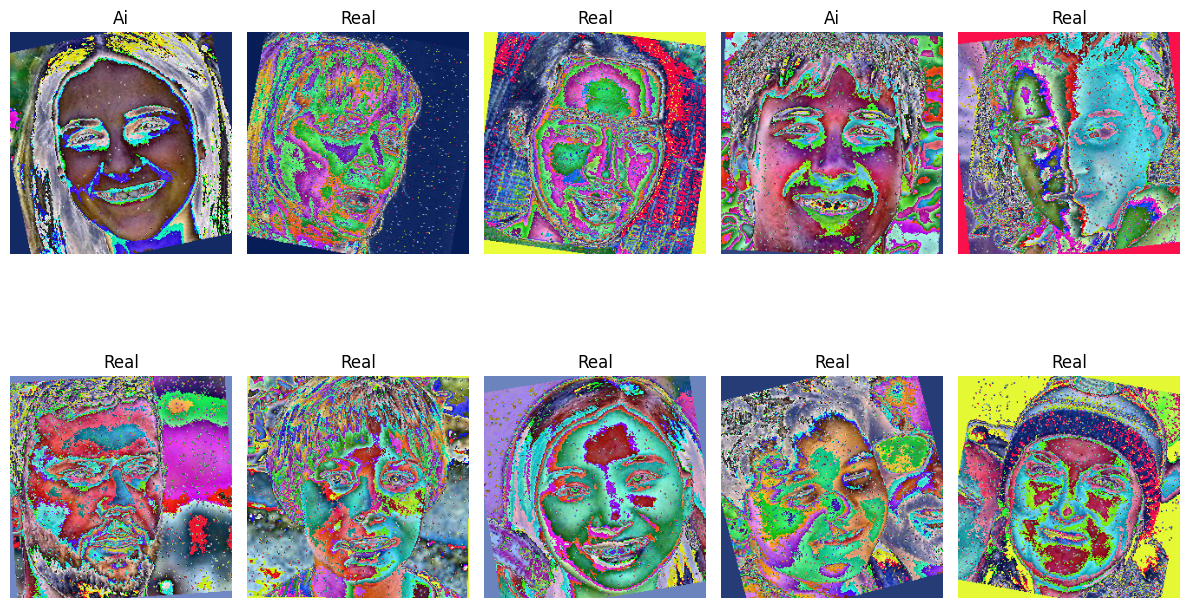

In [8]:
to_pil = transforms.ToPILImage()


def show_image(img):
    image = to_pil(img)
    plt.imshow(image)
    plt.axis("off")
    
    
dataiter = iter(train_loader)
_images, _labels = next(dataiter)
plt.figure(figsize=(12, 8))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    show_image(_images[i])
    plt.title("Real" if _labels[i].item() == 0 else "Ai")
    
plt.tight_layout()
plt.show()

# **MODEL MODULE**

In [9]:
class ResBlock(nn.Module):
    def __init__(self, in_channels, out_channels, stride=1):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, 3, stride=stride, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels)
        )
        self.shortcut = nn.Sequential()
        if stride != 1 or in_channels != out_channels:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_channels, out_channels, 1, stride=stride, bias=False),
                nn.BatchNorm2d(out_channels)
            )

    def forward(self, x):
        return nn.functional.relu(self.conv(x) + self.shortcut(x))


class Model(nn.Module):
    def __init__(self):
        super().__init__()

        self.features = nn.Sequential(
            ResBlock(3, 32, stride=2),
            ResBlock(32, 64, stride=2),
            ResBlock(64, 128, stride=2),
            ResBlock(128, 256, stride=2),
            nn.Dropout2d(0.3)
        )

        self.classifier = nn.Sequential(
            nn.AdaptiveAvgPool2d((1, 1)),
            nn.Flatten(),
            nn.Linear(256, 128),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),
            nn.Linear(128, 1)
        )

    def show_summary(self):
        summary(self, input_size=(3, 256, 256))
        return

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

# **MODEL**

In [10]:
MODEL = Model().to(DEVICE)
OPTIMIZER = optim.Adam(
    MODEL.parameters(),
    lr=LEARNING_RATE
)
MODEL

Model(
  (features): Sequential(
    (0): ResBlock(
      (conv): Sequential(
        (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
        (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): ReLU(inplace=True)
        (3): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (4): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
      (shortcut): Sequential(
        (0): Conv2d(3, 32, kernel_size=(1, 1), stride=(2, 2), bias=False)
        (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
    )
    (1): ResBlock(
      (conv): Sequential(
        (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
        (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): ReLU(inplace=True)
        (3): Conv2d(64, 64, kernel_size=(3,

In [11]:
MODEL.show_summary()

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1         [-1, 32, 128, 128]             864
       BatchNorm2d-2         [-1, 32, 128, 128]              64
              ReLU-3         [-1, 32, 128, 128]               0
            Conv2d-4         [-1, 32, 128, 128]           9,216
       BatchNorm2d-5         [-1, 32, 128, 128]              64
            Conv2d-6         [-1, 32, 128, 128]              96
       BatchNorm2d-7         [-1, 32, 128, 128]              64
          ResBlock-8         [-1, 32, 128, 128]               0
            Conv2d-9           [-1, 64, 64, 64]          18,432
      BatchNorm2d-10           [-1, 64, 64, 64]             128
             ReLU-11           [-1, 64, 64, 64]               0
           Conv2d-12           [-1, 64, 64, 64]          36,864
      BatchNorm2d-13           [-1, 64, 64, 64]             128
           Conv2d-14           [-1, 64,

In [12]:
def show_losses(
        train_F1_hist,
        train_accs_hist,
        val_F1_hist,
        val_accs_hist
):
    clear_output()

    plt.figure(figsize=(12, 4))
    plt.subplot(1, 2, 1)
    plt.plot(train_F1_hist, label="Train F1-Score")
    plt.plot(val_F1_hist, label="Val F1-Score")
    plt.xlabel("Epoch")
    plt.ylabel("F1-Score")
    plt.legend()
    plt.title("F1-Score curves")

    plt.subplot(1, 2, 2)
    plt.plot(train_accs_hist, label="Train acc")
    plt.plot(val_accs_hist, label="Val acc")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.title("Accuracy curves")

    plt.tight_layout()
    plt.show()

# **TRAIN MODULE**

In [13]:
def train(model, loader, optimizer):
    model.train()
    correct = 0
    
    metric_F1 = F1Score(task="binary")
    metric_F1.to(DEVICE)
    
    for image, labels in loader:
        image, labels = image.to(DEVICE), labels.to(DEVICE).unsqueeze(1)
        outputs = model(image)
        
        loss = criterion(outputs, labels.float())
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
                
        predictions = (outputs > 0).int()
        correct += (predictions == labels).sum().item()
        metric_F1.update(predictions, labels.int())
                
    accuracy = correct / len(loader.dataset)
    F1_score = metric_F1.compute()
    
    return accuracy, F1_score


@torch.inference_mode()  # torch.no_grad()
def evaluate(model, loader):
    model.eval()
    correct = 0
    
    metric_F1 = F1Score(task="binary")
    metric_F1.to(DEVICE)
    
    for image, labels in loader:
        image, labels = image.to(DEVICE), labels.to(DEVICE).unsqueeze(1)
        outputs = model(image)
        
        predictions = (outputs > 0).int()
        correct += (predictions == labels).sum().item()
        metric_F1.update(predictions, labels.int())
        
    accuracy = correct / len(loader.dataset)
    
    F1_score = metric_F1.compute()
    
    return accuracy, F1_score

# **RUN_TRAINING MODULE**

In [14]:
def run(
        model,
        _train_loader,
        _val_loader,
        optimizer,
        epochs: int = 10
):
    train_accs = []
    val_accs = []
    train_F1Scores = []
    val_F1Scores = []

    for epoch in range(epochs):
        train_acc, train_F1Score = train(
            model,
            _train_loader,
            optimizer
        )
        val_acc, val_F1Score = evaluate(
            model,
            _val_loader
        )

        train_accs.append(train_acc)
        val_accs.append(val_acc)
        train_F1Scores.append(train_F1Score)
        val_F1Scores.append(val_F1Score)
        
        show_losses(
            train_F1_hist=train_F1Scores,
            train_accs_hist=train_accs,
            val_F1_hist=val_F1Scores,
            val_accs_hist=val_accs
        )
        print(f"Epoch {epoch + 1}/{epochs} | Train F1-Score: {train_F1Score:.4f} | Train Acc: {train_acc:.4f} | Val F1-Score: {val_F1Score:.4f} | Val Acc: {val_acc:.4f}")
        
    return {
        "train_accs": train_accs,
        "val_accs": val_accs,
        "train_F1Score": train_F1Scores,
        "val_F1Score": val_F1Scores
    }

# **TRAINING**

In [15]:
history_data = run(
    model=MODEL,
    _train_loader=train_loader,
    _val_loader=val_loader,
    optimizer=OPTIMIZER,
    epochs=50
)

KeyboardInterrupt: 

# **SAVING MODEL WEIGHTS**

In [39]:
torch.save(MODEL.state_dict(), MODEL_WEIGHTS_PATH)

# **LOADING MODEL WEIGHTS**

In [ ]:
MODEL.load_state_dict(torch.load(MODEL_WEIGHTS_PATH))

# **TEST_DATASET MODULE**

In [39]:
all_test_data = load_all_data(
    root_dir=TEST_IMAGES_DIR
)

test_dataset = CustomDataset(
    data=all_test_data,
    _transform=base_transform
)

test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

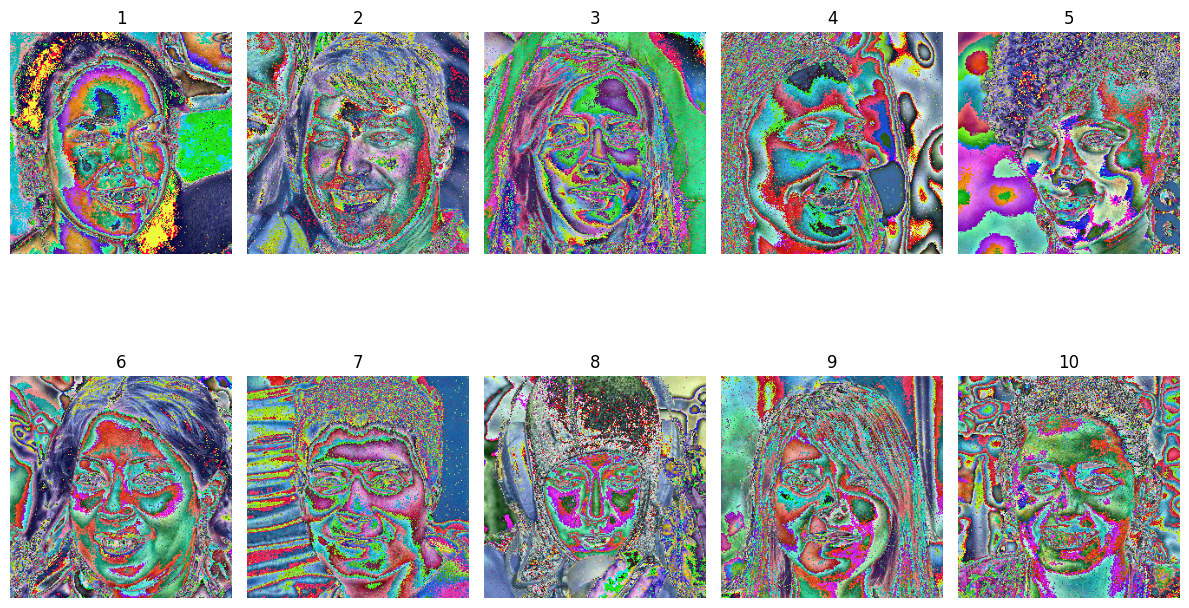

In [43]:
to_pil = transforms.ToPILImage()


def show_image(img):
    image = to_pil(img)
    plt.imshow(image)
    plt.axis("off")
    
    
dataiter = iter(test_loader)
_images, _labels = next(dataiter)
plt.figure(figsize=(12, 8))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    show_image(_images[i])
    plt.title(_labels[i].item() + 1)
    
plt.tight_layout()
plt.show()

# **PREDICT MODULE**

In [ ]:
@torch.inference_mode() # torch.no_grad()
def predict(model, _test_loader):
    model.eval()

    predictions = []

    for images, images_ids in _test_loader:
        images = images.to(DEVICE)

        outputs = model(images)
        probs = outputs.squeeze()

        predictions = (probs > 0.5).int().cpu().numpy()        
        for img_id, pred in zip(images_ids, predictions):
            predictions.append((img_id.item(), pred))

    return predictions

# **PREDICT**

In [ ]:
y = predict(MODEL, test_loader)
df = pd.DataFrame(y, columns=["id", "label"])
df = df.sort_values("id")
df